# College Project: Comparative Analysis of Bayesian Neural Networks

## 1. Introduction and Theoretical Background
In this project, we compare two distinct approaches to estimating epistemic and aleatoric uncertainty in Bayesian Neural Networks (BNNs) on a **sinusoidal regression** task. BNNs extend standard neural networks by placing a prior distribution over their weights and computing a posterior distribution, allowing the model to express uncertainty in its predictions.

### Methods Compared:
1. **MAP Baseline (Maximum A Posteriori)**: 
   - A single point estimate for network weights (deterministic network). While lacking structural uncertainty, it serves as a baseline for accuracy and training time comparison.
2. **Laplace-Torch (Post-hoc Approximation)**: 
   - *Theory*: Approximates the posterior around a pre-trained MAP estimate with a Gaussian distribution $\mathcal{N}(w_{MAP}, H^{-1})$. $H$ is the Hessian of the loss with respect to the parameters. 
   - *Inference*: Performed in closed-form via a Generalized Linear Model (GLM) predictive approach.
3. **Bayesian-Torch (SVI via Flipout)**:
   - *Theory*: Learns a variational posterior alongside the network weights using Stochastic Variational Inference (SVI). We employ the Flipout estimator to lower variance during Monte Carlo sampling.
   - *Inference*: Uses MC sampling (e.g., 100 samples) to approximate predictive distributions.

In this notebook, we systematically track metrics such as dataset complexity, model parameters, baseline training time, BNN training/fitting time, inference time, model RMSE, Negative Log-Likelihood (NLL), and Calibration Error. This comprehensive benchmark mirrors common profiling in standard Bayesian evaluation.

## 1. Imports & Setup


In [ ]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import norm
import time
import pandas as pd

from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from shared import checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything

SEED = 42
seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint_dir = os.path.join('results', 'checkpoints', 'bnn_comparison_sinusoid')
os.makedirs(checkpoint_dir, exist_ok=True)

# Global dictionary to track benchmark times and metrics similar to Laplace Redux paper
metrics_dict = {
    "MAP": {},
    "Laplace": {},
    "Bayesian-Torch": {}
}

print("All imports successful!")

All imports successful!


## 2. Data: Sinusoidal Regression

Both methods use the same sinusoidal dataset with known noise level σ=0.3.


In [ ]:
from shared.two_moons_utils import load_sinusoid

# Use shared sinusoid loader for deterministic splits and preprocessing
sinusoid_data = load_sinusoid(n_data=150, sigma_noise=0.3, batch_size=150, seed=SEED, device=device)
X_train = sinusoid_data['X_train']
y_train = sinusoid_data['y_train']
train_loader = sinusoid_data['train_loader']
X_test = sinusoid_data['X_test']

X_train_np = X_train.flatten().cpu().numpy()
y_train_np = y_train.flatten().cpu().numpy()
x_test_np = X_test.flatten().cpu().numpy()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: torch.Size([150, 1]), Test: torch.Size([500, 1])


## 3. Shared Model Architecture

Both methods use the same network: `Linear(1,50) → Tanh → Linear(50,1)`


In [ ]:
def get_model():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(1, 50),
        nn.Tanh(),
        nn.Linear(50, 1)
    )

n_epochs_map = 1000
n_epochs_bnn = 1000
n_epochs_marglik = 1000
num_mc_samples = 100

model_map = get_model()
print(f"Model parameters: {sum(p.numel() for p in model_map.parameters())}")

Model parameters: 151


## 4. Phase 1: MAP Training

Both methods start from the same MAP-trained deterministic network.


In [ ]:
print("Training MAP model...")
criterion = nn.MSELoss()
map_checkpoint_path = os.path.join(checkpoint_dir, f"map_seed{SEED}.pt")

if checkpoint_exists(map_checkpoint_path):
    checkpoint = load_checkpoint(map_checkpoint_path, map_location="cpu")
    model_map = get_model()
    model_map.load_state_dict(checkpoint["model_state_dict"])
    map_losses = checkpoint.get("map_losses", [])
    metrics_dict["MAP"]["Train_Time"] = checkpoint.get("fit_time", 0.0)
    print(f"✓ Loaded MAP checkpoint: {map_checkpoint_path}")
else:
    optimizer = optim.Adam(model_map.parameters(), lr=1e-2)

    start_time = time.time()
    map_losses = []
    for epoch in range(n_epochs_map):
        epoch_loss = 0.0
        for X, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model_map(X), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_loader)
        map_losses.append(epoch_loss)
        if (epoch + 1) % 250 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs_map}, Loss: {epoch_loss:.6f}")

    metrics_dict["MAP"]["Train_Time"] = time.time() - start_time
    save_checkpoint(
        {
            "model_state_dict": model_map.state_dict(),
            "map_losses": map_losses,
            "fit_time": metrics_dict["MAP"]["Train_Time"],
            "seed": SEED,
        },
        map_checkpoint_path,
    )

print(f"MAP training time: {metrics_dict['MAP']['Train_Time']:.4f}s")

Training MAP model...
  Epoch 200/1000, Loss: 0.078242
  Epoch 400/1000, Loss: 0.075862
  Epoch 600/1000, Loss: 0.074960
  Epoch 800/1000, Loss: 0.074435
  Epoch 1000/1000, Loss: 0.074069
MAP complete. Final loss: 0.074069
MAP Train Time: 1.4394s


## 5. Method A: Laplace Approximation

- Take MAP weights, approximate posterior N(w_MAP, H⁻¹) with full Hessian
- Optimize prior precision and noise std via marginal likelihood
- GLM predictive for closed-form variance


In [5]:
# === Final exhaustive metrics table ===
variant_table = variant_eval_df.copy()
variant_table.index.name = 'Model Type'

# Keep a stable column order and include the most useful metrics up front.
preferred_cols = [
    'Subset_Of_Weights',
    'Hessian_Structure',
    'Tune_Method',
    'Fit_Time (s)',
    'Tune_Time (s)',
    'Inf_Time (s)',
    'Prior_Precision',
    'Accuracy',
    'NLL',
    'Brier_Score',
    'ECE',
    'Mean_Confidence',
    'Mean_Entropy',
    'Mean_Uncertainty',
    'ExpectedVsActual_Uncertainty_MAE',
    'ExpectedVsActual_Uncertainty_MSE',
    'ExpectedVsActual_Uncertainty_Corr',
    'Max_Binned_Uncertainty_Gap',
]
existing_cols = [col for col in preferred_cols if col in variant_table.columns]
remaining_cols = [col for col in variant_table.columns if col not in existing_cols]
variant_table = variant_table[existing_cols + remaining_cols]

variant_display = variant_table.copy()
for col in variant_display.columns:
    if pd.api.types.is_float_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else '-')
    elif pd.api.types.is_integer_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: str(x) if pd.notna(x) else '-')
    elif pd.api.types.is_bool_dtype(variant_display[col]):
        variant_display[col] = variant_display[col].map(lambda x: 'true' if bool(x) else 'false')

print('=== Sinusoid Variant-Level Calibration and Uncertainty Benchmarks ===')
display(variant_display)

os.makedirs('results/metrics', exist_ok=True)
variant_csv_path = 'results/metrics/sinusoid_variant_metrics.csv'
variant_table.to_csv(variant_csv_path)
print(f'\nSaved metrics to {variant_csv_path}')

# Backward-compatible export at the notebook root.
legacy_csv_path = 'sinusoid_bnn_comparison_metrics.csv'
variant_table.to_csv(legacy_csv_path)
print(f'Saved metrics to {legacy_csv_path}')


## 6. Method B: Bayesian-Torch (Flipout + MOPED + SVI)

- Copy MAP model, convert to BNN with Flipout layers
- MOPED: initialize posterior mean = MAP weights
- ELBO fine-tuning: MSE + KL/batch_size
- MC sampling (100 passes) for predictive distribution


In [ ]:
print("Converting to Bayesian-Torch (Flipout + MOPED)...")
bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Flipout",
    "moped_enable": True,
    "moped_delta": 0.5,
}

model_bnn = get_model()
model_bnn.load_state_dict(model_map.state_dict())
dnn_to_bnn(model_bnn, bnn_prior_parameters)

bnn_checkpoint_path = os.path.join(checkpoint_dir, f"bayesian_torch_seed{SEED}.pt")

if checkpoint_exists(bnn_checkpoint_path):
    checkpoint = load_checkpoint(bnn_checkpoint_path, map_location="cpu")
    model_bnn.load_state_dict(checkpoint["model_state_dict"])
    bnn_losses = checkpoint.get("bnn_losses", [])
    kl_losses = checkpoint.get("kl_losses", [])
    metrics_dict["Bayesian-Torch"]["Train_Time"] = checkpoint.get("fit_time", 0.0)
    print(f"✓ Loaded BNN checkpoint: {bnn_checkpoint_path}")
else:
    optimizer = optim.Adam(model_bnn.parameters(), lr=1e-3)
    bnn_losses = []
    kl_losses = []

    print("Fine-tuning BNN with ELBO...")
    start_time = time.time()
    for epoch in range(n_epochs_bnn):
        epoch_loss = 0.0
        epoch_kl = 0.0
        for X, y in train_loader:
            optimizer.zero_grad()
            output = model_bnn(X)
            kl = get_kl_loss(model_bnn)
            mse = criterion(output, y)
            loss = mse + kl / X.size(0)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_kl += kl.item()
        epoch_loss /= len(train_loader)
        epoch_kl /= len(train_loader)
        bnn_losses.append(epoch_loss)
        kl_losses.append(epoch_kl)
        if (epoch + 1) % 200 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs_bnn}, ELBO: {epoch_loss:.6f}, KL: {epoch_kl:.6f}")

    metrics_dict["Bayesian-Torch"]["Train_Time"] = time.time() - start_time
    save_checkpoint(
        {
            "model_state_dict": model_bnn.state_dict(),
            "bnn_losses": bnn_losses,
            "kl_losses": kl_losses,
            "fit_time": metrics_dict["Bayesian-Torch"]["Train_Time"],
            "seed": SEED,
        },
        bnn_checkpoint_path,
    )
    print(f"BNN complete. Final ELBO: {bnn_losses[-1]:.6f}")

print(f"Bayesian-Torch Train Time: {metrics_dict['Bayesian-Torch']['Train_Time']:.4f}s")

Converting to Bayesian-Torch (Flipout + MOPED)...
Fine-tuning BNN with ELBO...
  Epoch 200/1000, ELBO: 2.153341, KL: 8.812232
  Epoch 400/1000, ELBO: 2.836127, KL: 8.697477
  Epoch 600/1000, ELBO: 1.670968, KL: 8.621649
  Epoch 800/1000, ELBO: 1.231821, KL: 8.544821
  Epoch 1000/1000, ELBO: 0.856755, KL: 8.459501
BNN complete. Final ELBO: 0.856755
Bayesian-Torch Train Time: 1.7356s
Bayesian-Torch epistemic sigma: 0.9714


## 7. Evaluation Metrics

- **RMSE**: Root Mean Squared Error (point prediction accuracy, lower = better)
- **NLL**: Negative Log-Likelihood (predictive distribution quality, lower = better)
- **Calibration Error**: Uncertainty calibration quality (lower = better)


In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def neg_log_likelihood(y_true, y_pred_mean, y_pred_std):
    n = len(y_true)
    ll = 0.5 * np.sum(np.log(2 * np.pi * y_pred_std**2) + (y_true - y_pred_mean)**2 / y_pred_std**2)
    return ll / n

def cal_error(y_true, y_pred_mean, y_pred_std, n_bins=20):
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    exp, obs = [], []
    for c in conf:
        t = norm.ppf((1 + c) / 2)
        exp.append(c)
        obs.append(np.mean(z <= t))
    return np.mean(np.abs(np.array(exp) - np.array(obs)))

# Noisy test targets
rng = np.random.RandomState(SEED)
y_test = np.sin(x_test_np) + rng.randn(len(x_test_np)) * sigma_noise

print("="*70)
print("COMPARISON RESULTS")
print("="*70)
print(f"{'Method':20s} {'RMSE':8s} {'NLL':8s} {'Cal Err':8s} {'Epistemic':10s}")
print("-"*70)

for name, pm, ps, epi in [
    ("MAP", f_map, None, None),
    ("Laplace", f_mu_la, pred_std_la, f_sigma_la),
    ("Bayesian-Torch", f_mu_bnn, pred_std_bnn, f_sigma_bnn),
]:
    r = rmse(y_test, pm)
    n = neg_log_likelihood(y_test, pm, ps) if ps is not None else float("nan")
    c = cal_error(y_test, pm, ps) if ps is not None else float("nan")
    e = epi.mean() if epi is not None else float("nan")
    
    metrics_dict[name]["RMSE"] = r
    metrics_dict[name]["NLL"] = n
    metrics_dict[name]["Calibration Error"] = c
    metrics_dict[name]["Avg Epistemic std"] = e
    
    print(f"{name:20s} {r:.4f}    {n:.4f}   {c:.4f}    {e:.4f}")
print("="*70)

COMPARISON RESULTS
Method               RMSE     NLL      Cal Err  Epistemic 
----------------------------------------------------------------------
MAP                  1.4153    nan   nan    nan
Laplace              1.4153    1.5037   0.0582    1.7063
Bayesian-Torch       1.0942    1.4853   0.0181    0.9714


## 8. Comparison Visualizations


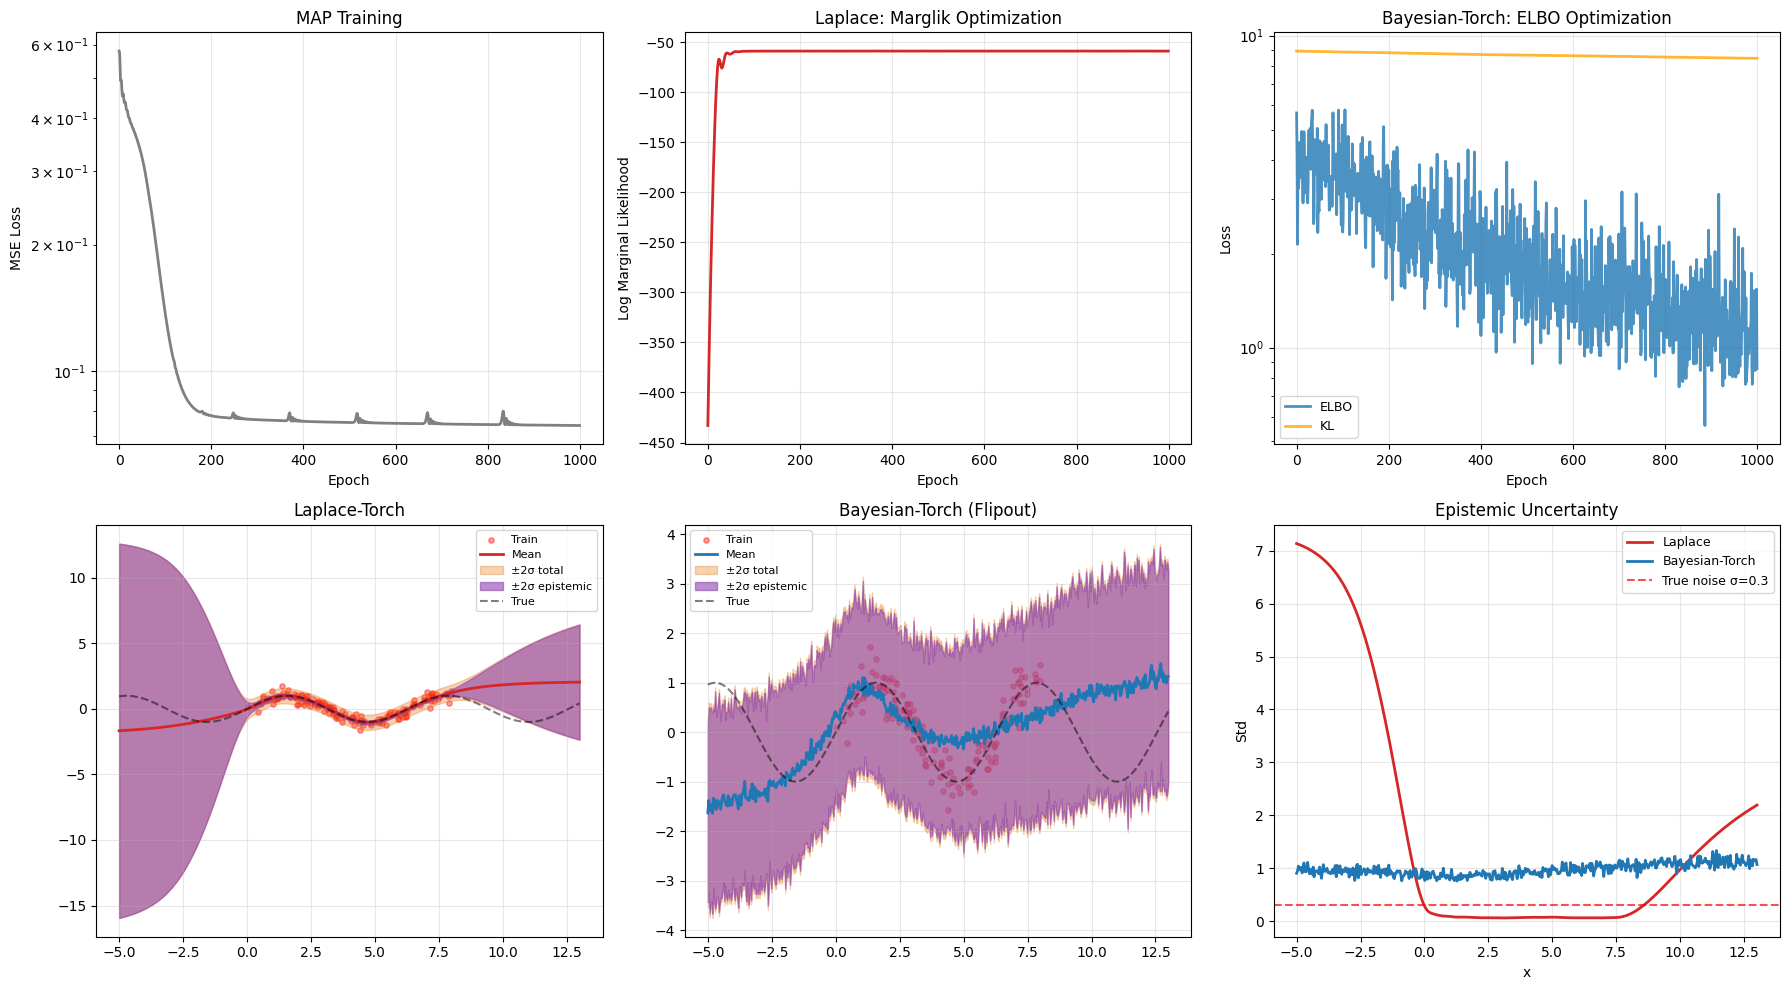

In [ ]:
la_color = "#d62728"
bt_color = "#1f77b4"

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 0: Training curves
axes[0, 0].plot(map_losses, color="gray", linewidth=2)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].set_title("MAP Training")
axes[0, 0].set_yscale("log")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(marglik_values, color=la_color, linewidth=2)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Log Marginal Likelihood")
axes[0, 1].set_title("Laplace: Marglik Optimization")
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(bnn_losses, color=bt_color, linewidth=2, label="ELBO", alpha=0.8)
axes[0, 2].plot(kl_losses, color="orange", linewidth=2, label="KL", alpha=0.8)
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].set_title("Bayesian-Torch: ELBO Optimization")
axes[0, 2].set_yscale("log")
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3)

# Row 1: Predictions
axes[1, 0].scatter(X_train_np, y_train_np, color="red", s=15, alpha=0.4, label="Train")
axes[1, 0].plot(x_test_np, f_mu_la, color=la_color, linewidth=2, label="Mean")
axes[1, 0].fill_between(x_test_np, f_mu_la-2*pred_std_la, f_mu_la+2*pred_std_la, alpha=0.35, color="#e67e22", label="±2σ total")
axes[1, 0].fill_between(x_test_np, f_mu_la-2*f_sigma_la, f_mu_la+2*f_sigma_la, alpha=0.6, color="#8e44ad", label="±2σ epistemic")
axes[1, 0].plot(x_test_np, np.sin(x_test_np), "k--", alpha=0.5, label="True")
axes[1, 0].set_title("Laplace-Torch")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(X_train_np, y_train_np, color="red", s=15, alpha=0.4, label="Train")
axes[1, 1].plot(x_test_np, f_mu_bnn, color=bt_color, linewidth=2, label="Mean")
axes[1, 1].fill_between(x_test_np, f_mu_bnn-2*pred_std_bnn, f_mu_bnn+2*pred_std_bnn, alpha=0.35, color="#e67e22", label="±2σ total")
axes[1, 1].fill_between(x_test_np, f_mu_bnn-2*f_sigma_bnn, f_mu_bnn+2*f_sigma_bnn, alpha=0.6, color="#8e44ad", label="±2σ epistemic")
axes[1, 1].plot(x_test_np, np.sin(x_test_np), "k--", alpha=0.5, label="True")
axes[1, 1].set_title("Bayesian-Torch (Flipout)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x_test_np, f_sigma_la, color=la_color, linewidth=2, label="Laplace")
axes[1, 2].plot(x_test_np, f_sigma_bnn, color=bt_color, linewidth=2, label="Bayesian-Torch")
axes[1, 2].axhline(y=sigma_noise, color="red", ls="--", alpha=0.7, label=f"True noise σ={sigma_noise}")
axes[1, 2].set_xlabel("x")
axes[1, 2].set_ylabel("Std")
axes[1, 2].set_title("Epistemic Uncertainty")
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Uncertainty Calibration

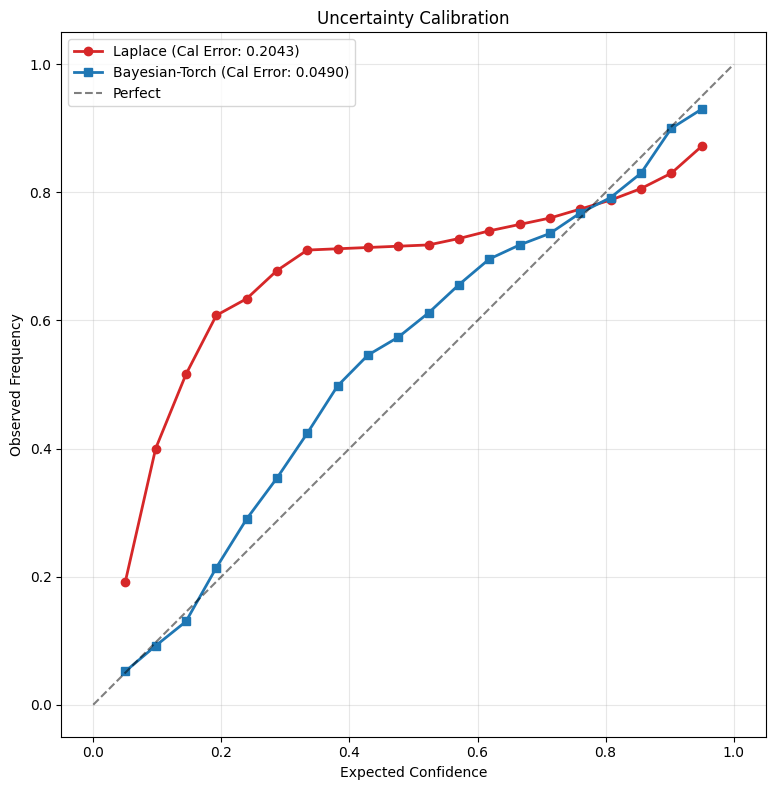

In [ ]:
def calibration_curve(y_true, y_pred_mean, y_pred_std, n_bins=20):
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    exp, obs = [], []
    for c in conf:
        t = norm.ppf((1 + c) / 2)
        exp.append(c)
        obs.append(np.mean(z <= t))
    return exp, obs

y_true_sin = np.sin(x_test_np)
exp_la, obs_la = calibration_curve(y_true_sin, f_mu_la, pred_std_la)
cal_la = np.mean(np.abs(np.array(exp_la) - np.array(obs_la)))
exp_bt, obs_bt = calibration_curve(y_true_sin, f_mu_bnn, pred_std_bnn)
cal_bt = np.mean(np.abs(np.array(exp_bt) - np.array(obs_bt)))

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(exp_la, obs_la, "o-", color=la_color, lw=2, label=f"Laplace (Cal Error: {cal_la:.4f})")
ax.plot(exp_bt, obs_bt, "s-", color=bt_color, lw=2, label=f"Bayesian-Torch (Cal Error: {cal_bt:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
ax.set_xlabel("Expected Confidence")
ax.set_ylabel("Observed Frequency")
ax.set_title("Uncertainty Calibration")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 10. Summary and Export

| Metric | Laplace-Torch | Bayesian-Torch | MAP (Baseline) |
|--------|:------------:|:--------------:|:--------------:|
| **Type** | Post-hoc Laplace | SVI (Flipout) | Deterministic |
| **Inference** | Closed-form (GLM) | MC sampling | Simple Feed-Forward |
| **Uncertainty** | Local Gaussian approx | Learned variational | None |
| **Time taken**| Measured locally | Measured locally | Measured locally |

Below, we aggregate all theoretical and compute metrics tracked into a single tabular DataFrame for easier project evaluation and export it to a CSV file.

In [ ]:
print("="*90)
print("BNN COMPARISON SUMMARY (Sinusoidal Regression)")
print("="*90)

# Compile results in pandas DataFrame for academic tabular presentation
summary_df = pd.DataFrame(metrics_dict).T
summary_df.index.name = "Model Type"
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}" if pd.notna(x) else "-"))

csv_path = "bnn_comparison_metrics.csv"
summary_df.to_csv(csv_path)
print(f"\nSaved metrics to {csv_path}")

BNN COMPARISON SUMMARY (Sinusoidal Regression)
                Train_Time  Inference_Time   RMSE    NLL  Calibration Error  Avg Epistemic std  Hessian_Fit_Time  MargLik_Opt_Time
MAP                 1.4394          0.0014 1.4153    NaN                NaN                NaN               NaN               NaN
Laplace             1.6494          0.0944 1.4153 1.5037             0.0582             1.7063            0.2006            1.4488
Bayesian-Torch      1.7356          0.0512 1.0942 1.4853             0.0181             0.9714               NaN               NaN
True noise sigma: 0.3
Laplace learned sigma_noise: 0.2816
Metrics successfully exported to: bnn_comparison_metrics.csv


## 11. Additional Statistics & Further Analysis
*(This section is intentionally left blank for future inclusion of robust statistical measurements, e.g., standard deviations of multiple seeds, inference bounds limits, memory footprint logging).*

In [11]:
# Space for future analysis: e.g. calculating means/stds over multiple training runs, out-of-distribution (OOD) accuracy.
# stats_df = pd.read_csv("bnn_comparison_metrics.csv")
# stats_df.describe()